# PCA - t-SNE , SVD

## PCA

PCA → preprocessing + visualization
t-SNE → mainly visualization

|                  | **PCA**                                   | **SVD**                                       |
| ---------------- | ----------------------------------------- | --------------------------------------------- |
| What it is       | Dimensionality-reduction method           | Matrix decomposition                          |
| Main use         | Reduce features while preserving variance | Decompose matrices / reduce dimensions        |
| Preprocessing    | ✅ Yes                                     | ✅ Yes                                         |
| Visualization    | ✅ Yes                                     | ✅ Yes                                         |
| Sparse data      | ⚠️ Less suitable                          | ✅ Very suitable with `TruncatedSVD`           |
| Centering        | Usually centers data                      | Does **not** center by default                |
| ML preprocessing | ✅ Common                                  | ✅ Common, especially sparse data              |
| NLP / text       | Less common                               | ⭐ Very common (`TruncatedSVD` / LSA)          |
| Relationship     | PCA can be computed using SVD             | SVD is often the mathematical tool behind PCA |

### Easy rule

* **PCA →** ordinary numerical data → dimensionality reduction
* **SVD →** matrix decomposition, especially **large/sparse matrices** such as text
* **t-SNE →** mainly visualization

For your **MNIST** dataset: **PCA is the more natural choice**.



## Notebook 2 — Dimensionality Reduction on MNIST

### 1. Why dimensionality reduction?

Each MNIST image is:

```text
28 × 28 = 784 features
```

So every image is a point in a **784-dimensional space**.

High-dimensional data can cause the **Curse of Dimensionality**:

* More computation and memory
* Distances become less informative
* Visualization becomes difficult/impossible
* Greater risk of overfitting

**Dimensionality reduction** means representing the data using fewer dimensions while trying to preserve important information.

---

## 2. Main methods you should know

| Category                 | Methods                                 | Main idea                                      | Main use                          |
| ------------------------ | --------------------------------------- | ---------------------------------------------- | --------------------------------- |
| **Linear, unsupervised** | PCA, TruncatedSVD, NMF, ICA             | Find a lower-dimensional linear representation | Reduction / preprocessing         |
| **Linear, supervised**   | LDA                                     | Find directions that separate classes          | Classification-oriented reduction |
| **Nonlinear**            | Kernel PCA                              | PCA in a nonlinear feature space               | Nonlinear reduction               |
| **Manifold learning**    | t-SNE, Isomap, LLE, Spectral, MDS, UMAP | Preserve structure/neighborhoods               | Mainly visualization              |

### The most important ones for you

**PCA**

* Linear dimensionality reduction
* Unsupervised
* Preserves maximum variance
* Can be used for preprocessing
* Very useful for MNIST

**SVD / TruncatedSVD**

* Matrix decomposition
* Can perform dimensionality reduction
* Particularly useful for **large/sparse matrices**
* Very common in text/NLP

**LDA**

* Supervised
* Uses class labels
* Tries to find projections that separate classes
* Useful when dimensionality reduction is connected to classification

**Kernel PCA**

* Nonlinear extension of PCA
* Useful when the structure isn't well represented by a linear projection

**t-SNE**

* Nonlinear
* Preserves local neighborhood structure
* Mainly used for **visualization**
* Excellent for seeing whether classes form clusters
* Generally not your choice for preprocessing a classifier

---

## 3. Other methods

The notebook also introduces:

* **NMF** — Non-negative Matrix Factorization
* **ICA** — Independent Component Analysis
* **Isomap**
* **LLE**
* **Spectral Embedding**
* **MDS**
* **UMAP**

You don't need to memorize all their mathematics initially. The important thing is knowing **what type of problem each method is designed for**.

---

## 4. Comparing PCA/SVD implementations

The notebook compares:

* PCA
* Randomized PCA
* Incremental PCA
* Truncated SVD

The focus is partly on **speed and scalability**.

For example:

* **PCA** → standard choice for normal dense numerical data
* **Randomized PCA** → faster approximation for large datasets
* **Incremental PCA** → useful when data is too large to process all at once
* **TruncatedSVD** → particularly useful for sparse matrices

---

## 5. Visualization

The notebook uses dimensionality reduction to visualize MNIST in **2D**.

For example:

```text
784 dimensions
      ↓
   PCA / t-SNE
      ↓
    2 dimensions
      ↓
     plot
```

This lets you visually inspect whether digits form separate clusters.

For example, you might see groups corresponding to:

```text
   0 0 0        3 3 3
  0 0 0 0      3 3 3
     8 8     5 5 5
    8 8 8
```

---

## 6. Quantitative comparison

The notebook doesn't only make plots. It also compares methods quantitatively.

Possible things to compare include:

* Explained variance
* Reconstruction quality
* Runtime
* Number of components
* Classification performance after reduction
* Quality of the resulting representation

---

## 7. Dimensionality reduction for classification

One important experiment is:

```text
Original MNIST
784 features
     ↓
PCA
     ↓
50 features
     ↓
MLP classifier
     ↓
Accuracy
```

Then compare it with:

```text
784 features
     ↓
MLP
     ↓
Accuracy
```

This tells you whether reducing the dimensionality actually helps or hurts your downstream model.

---

# What you should remember

If you're studying this for **ML/DL**, I'd prioritize these:

### ⭐ Must know

**PCA**
→ linear, unsupervised, variance preservation, preprocessing + visualization

**SVD**
→ matrix decomposition, dimensional reduction, especially useful for sparse/large matrices

**LDA**
→ supervised dimensional reduction using class labels

**t-SNE**
→ nonlinear visualization, especially useful for seeing clusters

**Kernel PCA**
→ nonlinear version of PCA

### Know conceptually

NMF, ICA, Isomap, LLE, Spectral Embedding, MDS, UMAP.

### Overall workflow

```text
MNIST: 784 dimensions
          │
          ├── PCA ──────────→ reduction / preprocessing
          │
          ├── SVD ──────────→ decomposition / reduction
          │
          ├── LDA ──────────→ class-oriented reduction
          │
          ├── Kernel PCA ────→ nonlinear reduction
          │
          └── t-SNE ─────────→ mainly visualization
```

So the **core lesson of the notebook** is not to memorize every algorithm. It's to understand **linear vs nonlinear, supervised vs unsupervised, preprocessing vs visualization, and when each dimensionality-reduction method is appropriate**.


The main difference is **how PCA handles the data and what kind of data/problem it is designed for**.

| Method                           | Main idea                            | Best for                              | Key difference                                       |
| -------------------------------- | ------------------------------------ | ------------------------------------- | ---------------------------------------------------- |
| **PCA**                          | Standard PCA using all data          | Normal-sized dense datasets           | Computes principal components from the whole dataset |
| **Incremental PCA**              | PCA learned in small batches         | Very large datasets                   | Doesn't need all data in memory at once              |
| **Kernel PCA**                   | PCA after a nonlinear transformation | Nonlinear structure                   | Can capture nonlinear relationships                  |
| **Truncated PCA / TruncatedSVD** | Keep only the first `k` components   | Large/high-dimensional or sparse data | Computes only a limited number of components         |

### 1. PCA

Standard PCA:

```text
X
 ↓
Center data
 ↓
Find directions of maximum variance
 ↓
Keep top k components
 ↓
Reduced X
```

Example:

```python
from sklearn.decomposition import PCA

pca = PCA(n_components=50)
X_reduced = pca.fit_transform(X)
```

For MNIST:

```text
784 dimensions → 50 dimensions
```

It's usually the **first method to try** for ordinary dense numerical data.

---

### 2. Incremental PCA

The problem with normal PCA is that it generally works with the dataset as a whole.

Incremental PCA processes data in **batches**:

```text
Batch 1 → update PCA
Batch 2 → update PCA
Batch 3 → update PCA
...
```

```python
from sklearn.decomposition import IncrementalPCA

ipca = IncrementalPCA(n_components=50, batch_size=256)

X_reduced = ipca.fit_transform(X)
```

Useful when:

```text
Dataset is huge
       ↓
Doesn't comfortably fit in RAM
       ↓
Process it batch-by-batch
```

So the important distinction is **memory/scalability**, not fundamentally a different goal from PCA.

---

### 3. Kernel PCA

Standard PCA is **linear**.

Imagine your data has a curved structure:

```text
     ● ●
   ●     ●
  ●       ●
   ●     ●
     ● ●
```

A straight-line PCA may not represent that structure well.

Kernel PCA uses a **kernel function** to implicitly map the data into another feature space where nonlinear structure can be represented.

```text
Original space
      ↓
Kernel transformation
      ↓
Higher-dimensional feature space
      ↓
PCA
      ↓
Reduced representation
```

```python
from sklearn.decomposition import KernelPCA

kpca = KernelPCA(
    n_components=2,
    kernel="rbf"
)

X_reduced = kpca.fit_transform(X)
```

Common kernels include:

```text
linear
rbf
poly
sigmoid
```

The important difference:

**PCA → linear dimensionality reduction**

**Kernel PCA → nonlinear dimensionality reduction**

---

### 4. Truncated PCA / TruncatedSVD

There is an important terminology point here.

In scikit-learn, you'll usually encounter **`TruncatedSVD`**, rather than a class literally called `TruncatedPCA`.

```python
from sklearn.decomposition import TruncatedSVD

svd = TruncatedSVD(n_components=50)
X_reduced = svd.fit_transform(X)
```

It uses a truncated SVD:

```text
X = U Σ Vᵀ

       ↓

Keep only the first k components

X ≈ Uₖ Σₖ Vₖᵀ
```

The big advantage is that it works particularly well with **sparse matrices**.

For example, NLP:

```text
Documents × Words
       ↓
Huge sparse matrix
       ↓
TruncatedSVD
       ↓
Lower-dimensional representation
```

This is commonly associated with **Latent Semantic Analysis (LSA)**.

---

## The easiest way to remember

Think about **what problem each one solves**:

```text
                    PCA family
                        │
        ┌───────────────┼────────────────┐
        │               │                │
      PCA        Incremental PCA     Kernel PCA
        │               │                │
   normal data     huge data        nonlinear data
   dense data      batches          nonlinear structure


             TruncatedSVD
                  │
          large/sparse data
          especially NLP
```

### For your MNIST project

I'd think about them like this:

| Method              | MNIST use                                                                        |
| ------------------- | -------------------------------------------------------------------------------- |
| **PCA**             | ⭐ Very appropriate                                                               |
| **Incremental PCA** | Useful if dataset is too large for memory                                        |
| **Kernel PCA**      | Interesting for nonlinear structure, but computationally expensive               |
| **TruncatedSVD**    | Possible, but more naturally useful for sparse/high-dimensional data such as NLP |

And one subtle but important point:

**PCA and TruncatedSVD are closely related mathematically.** PCA on centered data can be computed using SVD. `TruncatedSVD` differs in particular because it **does not center the data by default**, which is one reason it is convenient for sparse matrices.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA,TruncatedSVD,IncrementalPCA,KernelPCA

from sklearn.manifold import TSNE
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import make_pipeline

In [3]:
mnist = fetch_openml('mnist_784')

In [4]:
X = mnist['data'].astype('float32')
y = mnist['target'].astype('int64')

In [5]:
X = X/255.0

In [6]:
X_train,X_test,y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [7]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((56000, 784), (56000,), (14000, 784), (14000,))

In [142]:
pca_full = PCA(random_state=42)
pca_full.fit(X_train)

### Explained variance
explained_var = pca_full.explained_variance_ratio_
print(pca_full.n_components_)
print(len(explained_var))
print("Explained variance of first 10 components:")
print(explained_var[:10])

print('\n')

### Cumulative Explained variance
cumulative_var = np.cumsum(explained_var)
print(cumulative_var[:11])
## shows you sum of the k component var
print("Variance after 10 components:",
      cumulative_var[9])

print("Variance after 50 components:",
      cumulative_var[49])
# Variance after 50 components: 0.82561356 : using 50 first component explain 80 percent of var

784
784
Explained variance of first 10 components:
[0.09758723 0.07155355 0.06171034 0.05394776 0.04899099 0.04309515
 0.03269745 0.02888751 0.0275408  0.02337461]


[0.09758723 0.16914079 0.23085113 0.2847989  0.33378989 0.37688503
 0.40958247 0.43846998 0.46601078 0.4893854  0.5105568 ]
Variance after 10 components: 0.4893854
Variance after 50 components: 0.82561356


In [143]:
# Find components for
#    90%, 95%, 99% variance

for threshold in [0.90, 0.95, 0.99]:
    n_components = np.argmax(cumulative_var >= threshold)
    print(
        f"{threshold*100:.0f}% variance → "
        f"{n_components} components"
    )



n_components

90% variance → 86 components
95% variance → 153 components
99% variance → 330 components


330

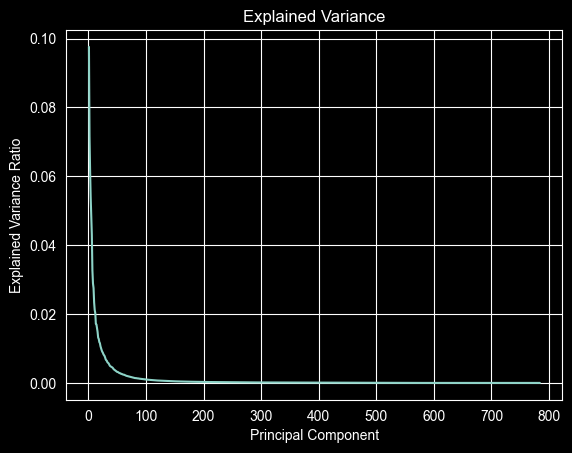

In [144]:
# 5. Plot explained variance
plt.plot(range(1, len(explained_var) + 1),
    explained_var
)
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("Explained Variance")

plt.show()


<BarContainer object of 10 artists>

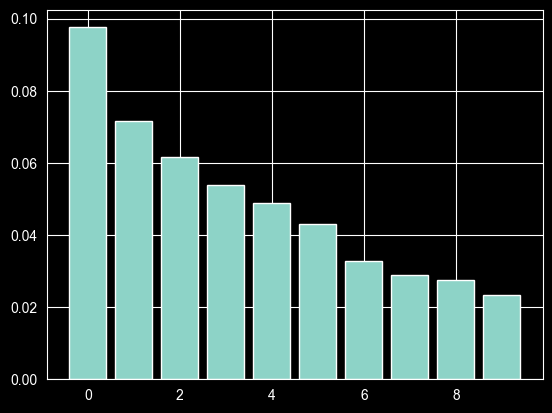

In [145]:
# 5. Plot explained variance

plt.bar(range(0,10),explained_var[:10])


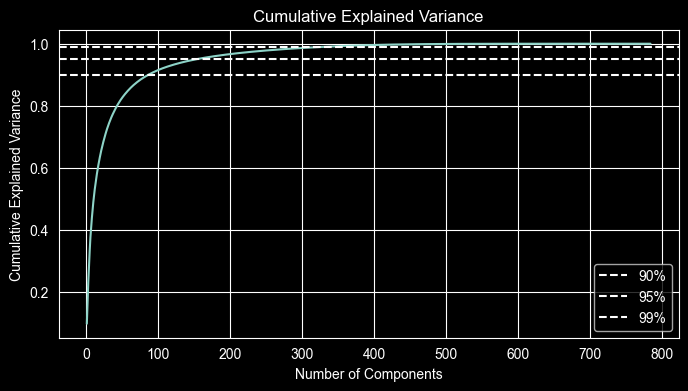

In [146]:
# 6. Plot cumulative variance
plt.figure(figsize=(8, 4))

plt.plot(
    range(1, len(cumulative_var) + 1),
    cumulative_var)

plt.axhline(0.90, linestyle="--", label="90%")
plt.axhline(0.95, linestyle="--", label="95%")
plt.axhline(0.99, linestyle="--", label="99%")

plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Explained Variance")
plt.legend()

plt.show()

<BarContainer object of 10 artists>

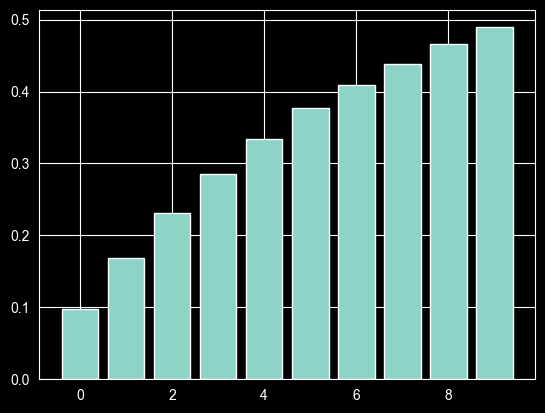

In [147]:
plt.bar(range(0,10),cumulative_var[:10])


In [148]:
## 7. Reduce dimensions
pca = PCA(n_components=50, random_state=42)

X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

print("Original shape:", X_train.shape)
print("Reduced shape:", X_train_pca.shape)

#8. Check how much variance
#    the 50 components retain
print(
    "Variance retained by 50 components:",
    pca.explained_variance_ratio_.sum()
)


Original shape: (56000, 784)
Reduced shape: (56000, 50)
Variance retained by 50 components: 0.8256136


In [149]:
pca = PCA(n_components=.95, random_state=42)
pca.fit(X_train)
X_train_pca = pca.transform(X_train)
X_train_pca.shape

(56000, 154)

In [150]:
print(len(pca.explained_variance_))
cumulative_pca = np.cumsum(pca.explained_variance_ratio_)
cumulative_pca[153]

154


0.95041263

PCA.fit(X)

     ↓

learn principal components

     ↓

explained_variance_ratio_

     ↓

how much variance each component captures

     ↓

np.cumsum(...)

     ↓

how much variance first k components capture

     ↓

PCA(n_components=50)

     ↓

fit_transform()

     ↓

784 → 50 dimensions

The key idea is that each PCA component is a vector of 784 numbers, so for MNIST you can reshape it into a 28 × 28 image and visualize what pattern that component represents.

In [151]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# PCA keeping 95% of the variance
pca = PCA(n_components=0.95, random_state=42)

X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

print("Original shape:", X_train.shape)
print("Reduced shape:", X_train_pca.shape)
print("Number of components:", pca.n_components_)
print("Variance retained:", pca.explained_variance_ratio_.sum())

Original shape: (56000, 784)
Reduced shape: (56000, 154)
Number of components: 154
Variance retained: 0.9504128


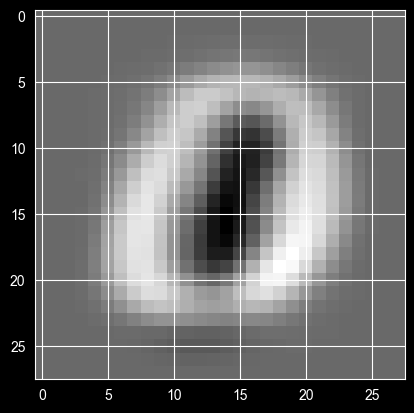

In [152]:
plt.imshow(components[0].reshape(28, 28), cmap="gray")

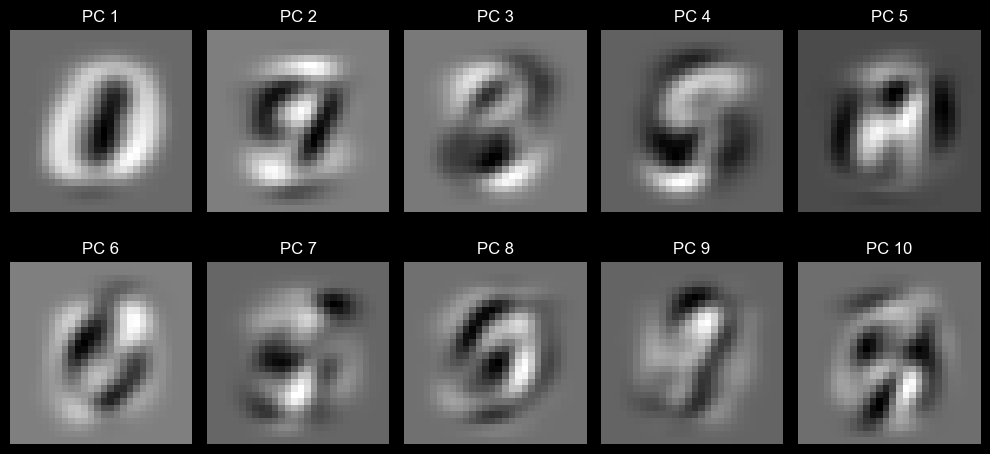

In [153]:
components = pca.components_

fig, axes = plt.subplots(2, 5, figsize=(10, 5))

for i, ax in enumerate(axes.flat):
    ax.imshow(components[i].reshape(28, 28), cmap="gray")
    ax.set_title(f"PC {i+1}")
    ax.axis("off")

plt.tight_layout()
plt.show()

In [154]:
len(components)

154

In [155]:
components[0].shape

(784,)

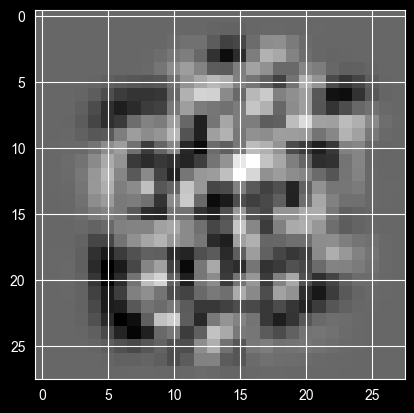

In [156]:
img_mean = np.mean(components,axis=0)
plt.imshow(img_mean.reshape(28, 28), cmap="gray")

In [157]:
pca = PCA(n_components=2, random_state=42)
X_train_pca = pca.fit_transform(X_train)


In [158]:
X_train_pca.shape

(56000, 2)

In [159]:
comps =pca.components_
len(comps)

2

In [160]:
comps.shape

(2, 784)

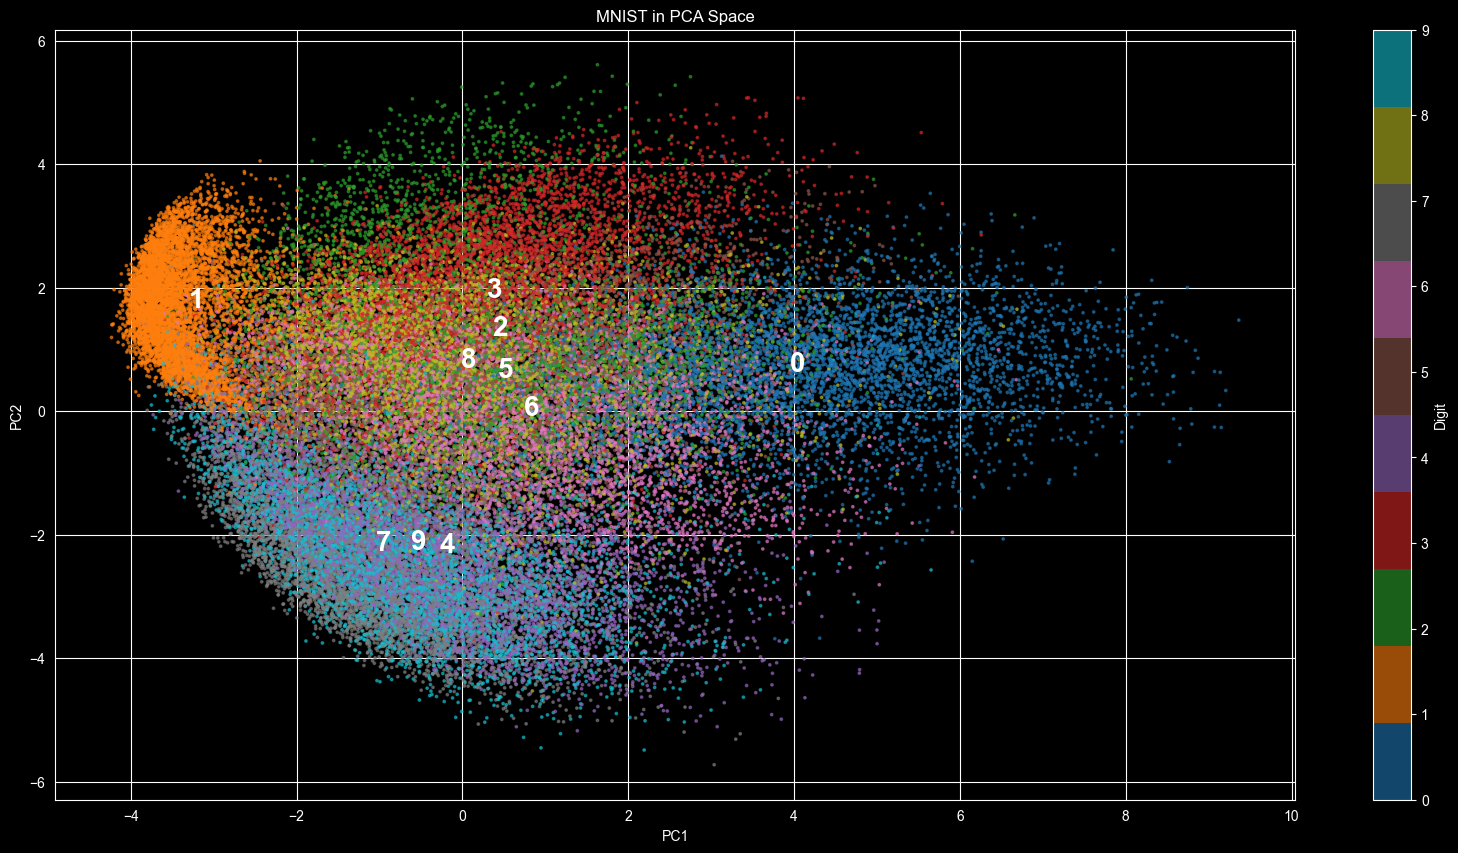

In [161]:
plt.figure(figsize=(20, 10))
plt.scatter(
    X_train_pca[:, 0],   # PC1
    X_train_pca[:, 1],   # PC2
    c=y_train,
    cmap="tab10",
    s=3,
    alpha=0.6
)
# Put the digit number at the center of each class
for digit in range(10):
    x = X_train_pca[y_train == digit, 0].mean()
    y = X_train_pca[y_train == digit, 1].mean()

    plt.text(
        x, y,
        str(digit),
        fontsize=20,
        fontweight="bold"
    )


plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("MNIST in PCA Space")
plt.colorbar(label="Digit")

plt.show()

IndexError: index 2 is out of bounds for axis 1 with size 2

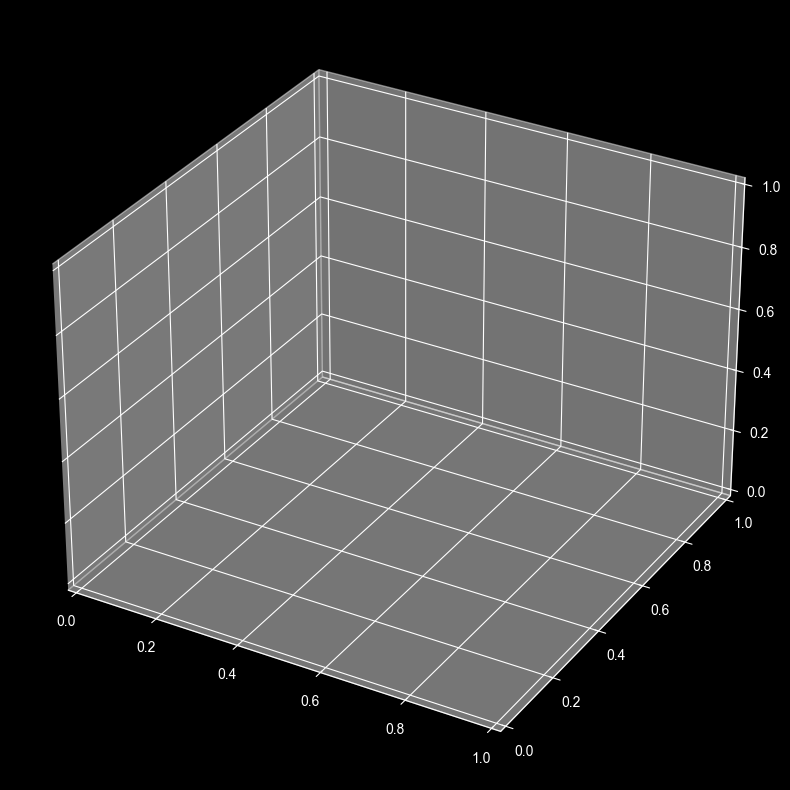

In [162]:
fig = plt.figure(figsize=(14, 10))

ax = fig.add_subplot(111, projection="3d")

sc = ax.scatter(
    X_train_pca[:, 0],   # PC1
    X_train_pca[:, 1],   # PC2
    X_train_pca[:, 2],   # PC3
    c=y_train,
    cmap="tab10",
    s=3,
    alpha=0.6
)

# Put digit number at the center of each class
for digit in range(10):
    mask = y_train == digit

    x = X_train_pca[mask, 0].mean()
    y = X_train_pca[mask, 1].mean()
    z = X_train_pca[mask, 2].mean()

    ax.text(
        x, y, z,
        str(digit),
        fontsize=18,
        fontweight="bold"
    )

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")

ax.set_title("MNIST in First 3 PCA Components")

fig.colorbar(sc, ax=ax, label="Digit")

plt.show()

Yes. This section is about **PCA reconstruction**: how well can we rebuild the original image if we keep only the first `k` principal components?

### Concept

You already have:

```python
pca_full = PCA()
pca_full.fit(X_train)
```

PCA learned:

* the **mean image** → `pca_full.mean_`
* the **principal components** → `pca_full.components_`

For reconstruction, we choose only the first `k` components.

* `k = 1` → very little information → blurry/rough image
* `k = 10` → more information
* `k = 50` → much better
* `k = 100` → better again
* `k = 784` → essentially all PCA information → reconstruction is very close to the original

So the experiment asks:

> **How much can I compress an image while still keeping its important information?**

---



In [163]:
pca_full = PCA()
pca_full.fit(X_train)

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",None
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized S

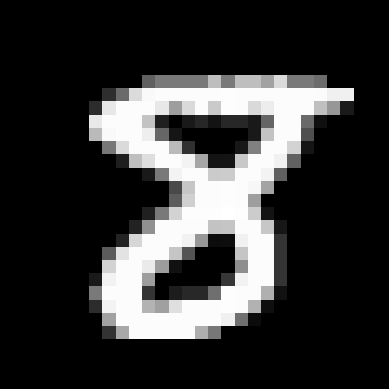

In [164]:
img = X_test.iloc[0].values

plt.imshow(img.reshape(28, 28), cmap="gray")
plt.axis("off")
plt.show()

In [165]:
components_50 = pca_full.components_[:50]


In [166]:
# Center the image
centered = image - pca_full.mean_

# Project image onto 50 components
X_50 = centered @ components_50.T

# Reconstruct image
reconstructed = X_50 @ components_50 + pca_full.mean_

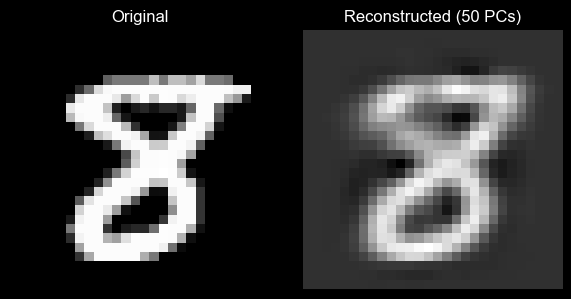

In [167]:
image = X_test.iloc[0].values

# First 50 PCA components
components_50 = pca_full.components_[:50]

# Project
centered = image - pca_full.mean_
X_50 = centered @ components_50.T

# Reconstruct
reconstructed = X_50 @ components_50 + pca_full.mean_

# Plot
fig, axes = plt.subplots(1, 2, figsize=(6, 3))

axes[0].imshow(image.reshape(28, 28), cmap="gray")
axes[0].set_title("Original")

axes[1].imshow(reconstructed.reshape(28, 28), cmap="gray")
axes[1].set_title("Reconstructed (50 PCs)")

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()

In [168]:
pca_50 = PCA(n_components=50)

X_train_50 = pca_50.fit_transform(X_train)

In [169]:
image = X_test.iloc[0].values

# Reduce to 50 dimensions
image_50 = pca_50.transform(image.reshape(1, -1))

# Reconstruct back to 784 pixels
reconstructed = pca_50.inverse_transform(image_50)

C:\Users\top\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


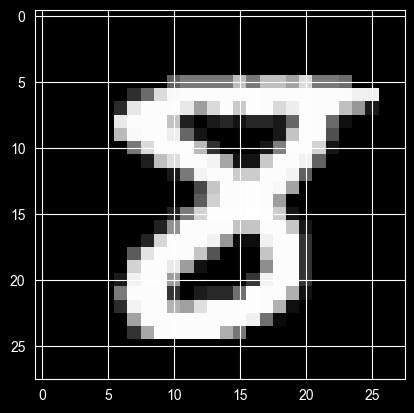

In [170]:
plt.imshow(img.reshape(28, 28), cmap="gray")

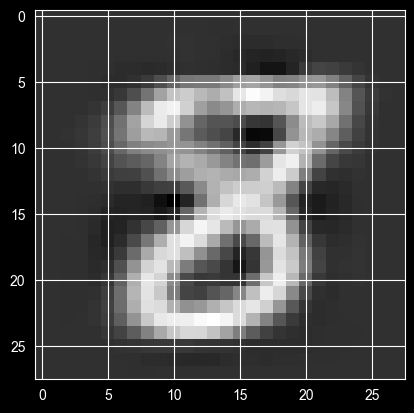

In [171]:
plt.imshow(reconstructed.reshape(28, 28), cmap="gray")

## SVD

In [178]:
svd = TruncatedSVD(random_state=42)
svd.fit(X_train)
len(svd.components_)

2

In [179]:
svd.components_.shape
#Because TruncatedSVD() has a default n_components=2.

(2, 784)

In [183]:
pca = PCA(random_state=42)
pca.fit(X_train)
print(len(pca.components_))
print(pca.components_.shape)

784
(784, 784)


In [194]:
svd = TruncatedSVD(random_state=42,n_components=784)
svd.fit(X_train)

,"n_components n_components: int, default=2Desired dimensionality of output data.If algorithm='arpack', must be strictly less than the number of features.If algorithm='randomized', must be less than or equal to the number of features.The default value is useful for visualisation. For LSA, a value of100 is recommended.",784
,"random_state random_state: int, RandomState instance or None, default=NoneUsed during randomized svd. Pass an int for reproducible results acrossmultiple function calls.See :term:`Glossary <random_state>`.",42
,"algorithm algorithm: {'arpack', 'randomized'}, default='randomized'SVD solver to use. Either ""arpack"" for the ARPACK wrapper in SciPy(scipy.sparse.linalg.svds), or ""randomized"" for the randomizedalgorithm due to Halko (2009).",'randomized'
,"n_iter n_iter: int, default=5Number of iterations for randomized SVD solver. Not used by ARPACK. Thedefault is larger than the default in:func:`~sklearn.utils.extmath.randomized_svd` to handle sparsematrices that may have large slowly decaying spectrum.",5
,"n_oversamples n_oversamples: int, default=10Number of oversamples for randomized SVD solver. Not used by ARPACK.See :func:`~sklearn.utils.extmath.randomized_svd` for a completedescription... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized SVD solver.Not used by ARPACK. See :func:`~sklearn.utils.extmath.randomized_svd`for more details... versionadded:: 1.1",'auto'
,"tol tol: float, default=0.0Tolerance for ARPACK. 0 means machine precision. Ignored by randomizedSVD solver.",0.0
Name,Type,Value
"components_ components_: ndarray of shape (n_components, n_features)The right singular vectors of the input data.","ndarray[float32](784, 784)","[[-0.,-0.,-0.,...,-0.,-0.,-0.], [ 0., 0.,-0.,...,-0.,-0.,-0.], [ 0., 0., 0.,..., 0., 0., 0.], ..., [ 0., 0., 0.,..., 0., 1., 0.], [ 0., 0., 0.,..., 0., 0., 1.], [ 1.,-0., 0.,...,-0.,-0.,-0.]]"
"explained_variance_ explained_variance_: ndarray of shape (n_components,)The variance of the training samples transformed by a projection toeach component.","ndarray[float32](784,)","[3.08,4.38,3.78,...,0. ,0. ,0. ]"
"explained_variance_ratio_ explained_variance_ratio_: ndarray of shape (n_components,)Percentage of variance explained by each of the selected components.","ndarray[float32](784,)","[0.06,0.08,0.07,...,0. ,0. ,0. ]"


In [195]:
svd.components_.shape


(784, 784)

In [196]:
exp_var=svd.explained_variance_ratio_
exp_var

array([5.83567098e-02, 8.28650221e-02, 7.15489388e-02, 6.13315888e-02,
       5.29339463e-02, 4.31455262e-02, 3.61938439e-02, 2.90520042e-02,
       2.88126525e-02, 2.34327987e-02, 2.13330537e-02, 2.05908157e-02,
       1.71667952e-02, 1.70527957e-02, 1.59858130e-02, 1.48831643e-02,
       1.35490615e-02, 1.29519505e-02, 1.18706590e-02, 1.15559306e-02,
       1.06648142e-02, 1.00887939e-02, 9.55471862e-03, 9.09979735e-03,
       8.83825403e-03, 8.39216541e-03, 8.10395181e-03, 7.86251109e-03,
       7.42354151e-03, 6.87640160e-03, 6.58271881e-03, 6.44169422e-03,
       6.02010963e-03, 5.89258736e-03, 5.70039079e-03, 5.43050840e-03,
       5.05759101e-03, 4.87280404e-03, 4.76936763e-03, 4.67247237e-03,
       4.54821298e-03, 4.44499170e-03, 4.20908118e-03, 3.97252338e-03,
       3.85465682e-03, 3.75868171e-03, 3.61188757e-03, 3.50616011e-03,
       3.38504650e-03, 3.20860394e-03, 3.18103423e-03, 3.09503335e-03,
       2.94914283e-03, 2.89405766e-03, 2.82763201e-03, 2.69529200e-03,
      

In [197]:
cumulative = np.cumsum(exp_var)
cumulative

array([0.05835671, 0.14122173, 0.21277067, 0.27410227, 0.3270362 ,
       0.37018174, 0.4063756 , 0.4354276 , 0.46424025, 0.48767304,
       0.5090061 , 0.5295969 , 0.5467637 , 0.5638165 , 0.5798023 ,
       0.59468544, 0.6082345 , 0.6211865 , 0.6330572 , 0.6446131 ,
       0.6552779 , 0.6653667 , 0.67492145, 0.68402123, 0.6928595 ,
       0.7012516 , 0.7093556 , 0.7172181 , 0.7246416 , 0.73151803,
       0.73810077, 0.7445425 , 0.7505626 , 0.7564552 , 0.7621556 ,
       0.7675861 , 0.7726437 , 0.7775165 , 0.78228587, 0.78695834,
       0.7915065 , 0.79595155, 0.80016065, 0.8041332 , 0.8079878 ,
       0.8117465 , 0.81535834, 0.8188645 , 0.8222496 , 0.82545817,
       0.8286392 , 0.83173424, 0.83468336, 0.8375774 , 0.84040505,
       0.8431003 , 0.845775  , 0.84835386, 0.8508955 , 0.85333645,
       0.8557324 , 0.85811317, 0.8604107 , 0.8626184 , 0.8647455 ,
       0.8668129 , 0.8688339 , 0.8707836 , 0.8726954 , 0.8745818 ,
       0.8764533 , 0.87826645, 0.88002956, 0.88175744, 0.88340

In [198]:
svd.explained_variance_ratio_.sum()

0.99999446

In [200]:
for threshold in [.90,.95,.99]:
    n_components = np.argmax(cumulative >= threshold)
    print(
        f"{threshold*100:.0f}% variance → "
        f"{n_components} components"
    )



90% variance → 86 components
95% variance → 153 components
99% variance → 330 components


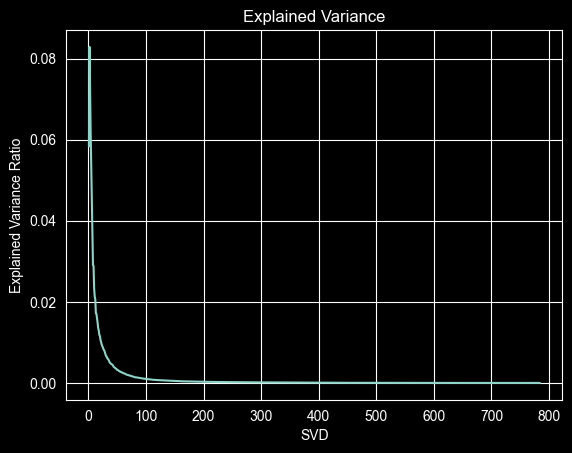

In [202]:
plt.plot(range(1, len(exp_var) + 1),
    exp_var
)
plt.xlabel("SVD")
plt.ylabel("Explained Variance Ratio")
plt.title("Explained Variance")

plt.show()

<BarContainer object of 10 artists>

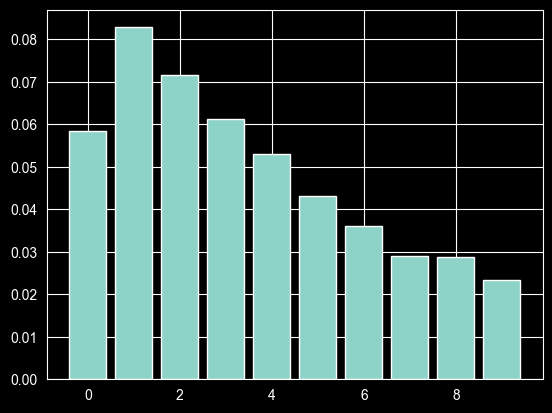

In [203]:
# 5. Plot explained variance

plt.bar(range(0,10),exp_var[:10])


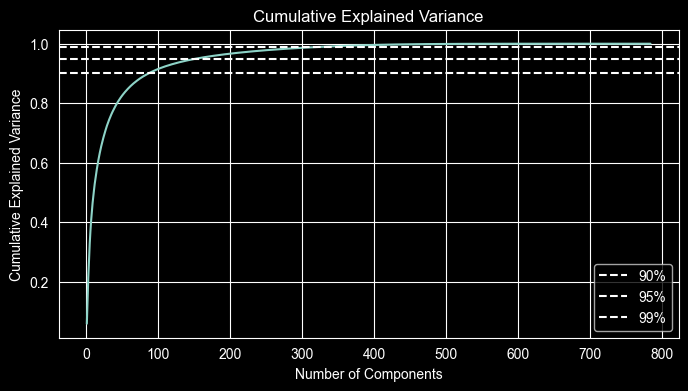

In [205]:
# 6. Plot cumulative variance
plt.figure(figsize=(8, 4))

plt.plot(
    range(1, len(cumulative) + 1),
    cumulative)

plt.axhline(0.90, linestyle="--", label="90%")
plt.axhline(0.95, linestyle="--", label="95%")
plt.axhline(0.99, linestyle="--", label="99%")

plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Explained Variance")
plt.legend()

plt.show()

<BarContainer object of 10 artists>

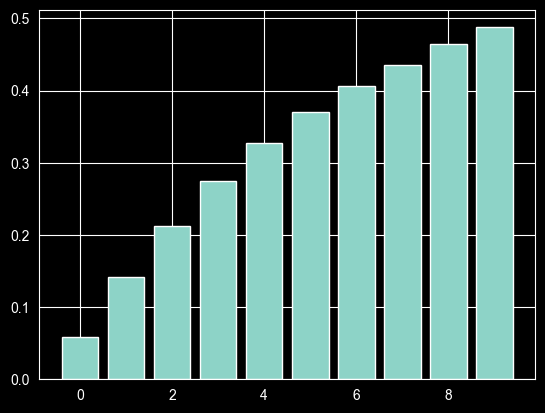

In [206]:
plt.bar(range(0,10),cumulative[:10])


In [217]:
svd = TruncatedSVD(n_components=50)
X_train_svd = svd.fit_transform(X_train)
X_test_svd = svd.transform(X_test)

print("Original shape:", X_train_svd.shape)
print("Reduced shape:", X_train_svd.shape)

#8. Check how much variance
#    the 50 components retain
print(
    "Variance retained by 50 components:",
    svd.explained_variance_ratio_.sum(),
    np.cumsum(svd.explained_variance_ratio_[49])
)


Original shape: (56000, 50)
Reduced shape: (56000, 50)
Variance retained by 50 components: 0.82535493 [0.00319646]


In [228]:
svd = TruncatedSVD(n_components=100, random_state=42)

X_train_svd = svd.fit_transform(X_train)
X_test_svd = svd.transform(X_test)

print("Original shape:", X_train.shape)
print("Reduced shape:", X_train_svd.shape)
print("Number of components:", len(svd.components_))
print("Variance retained:", svd.explained_variance_ratio_.sum())

Original shape: (56000, 784)
Reduced shape: (56000, 100)
Number of components: 100
Variance retained: 0.9148617


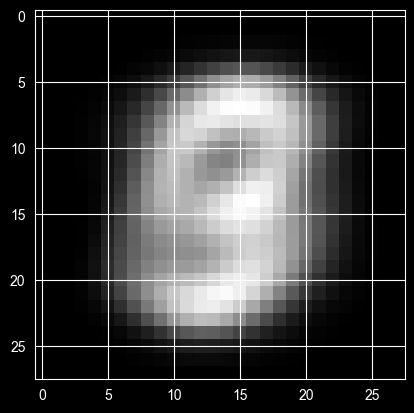

In [230]:
components = svd.components_
plt.imshow(components[0].reshape(28, 28), cmap="gray")

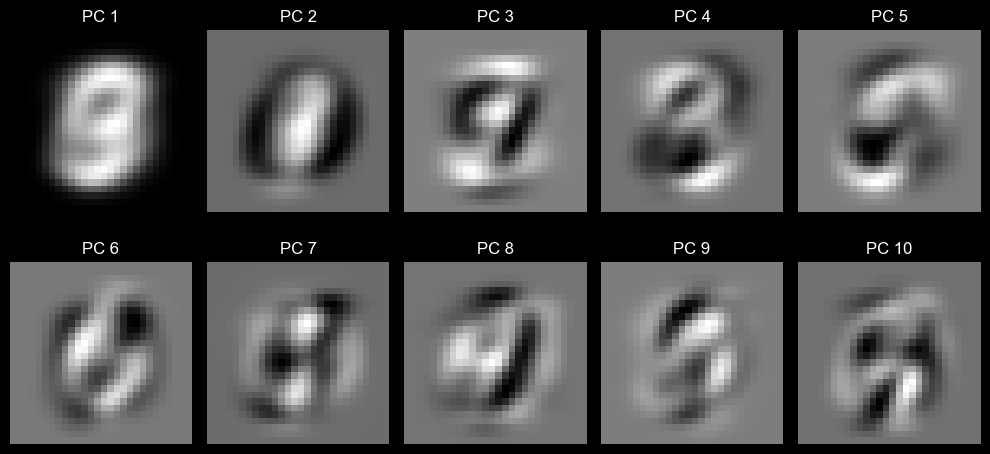

In [232]:
components = svd.components_

fig, axes = plt.subplots(2, 5, figsize=(10, 5))

for i, ax in enumerate(axes.flat):
    ax.imshow(components[i].reshape(28, 28), cmap="gray")
    ax.set_title(f"PC {i+1}")
    ax.axis("off")

plt.tight_layout()
plt.show()

In [237]:
svd = TruncatedSVD(n_components=2)
X_train_svd = svd.fit_transform(X_train)


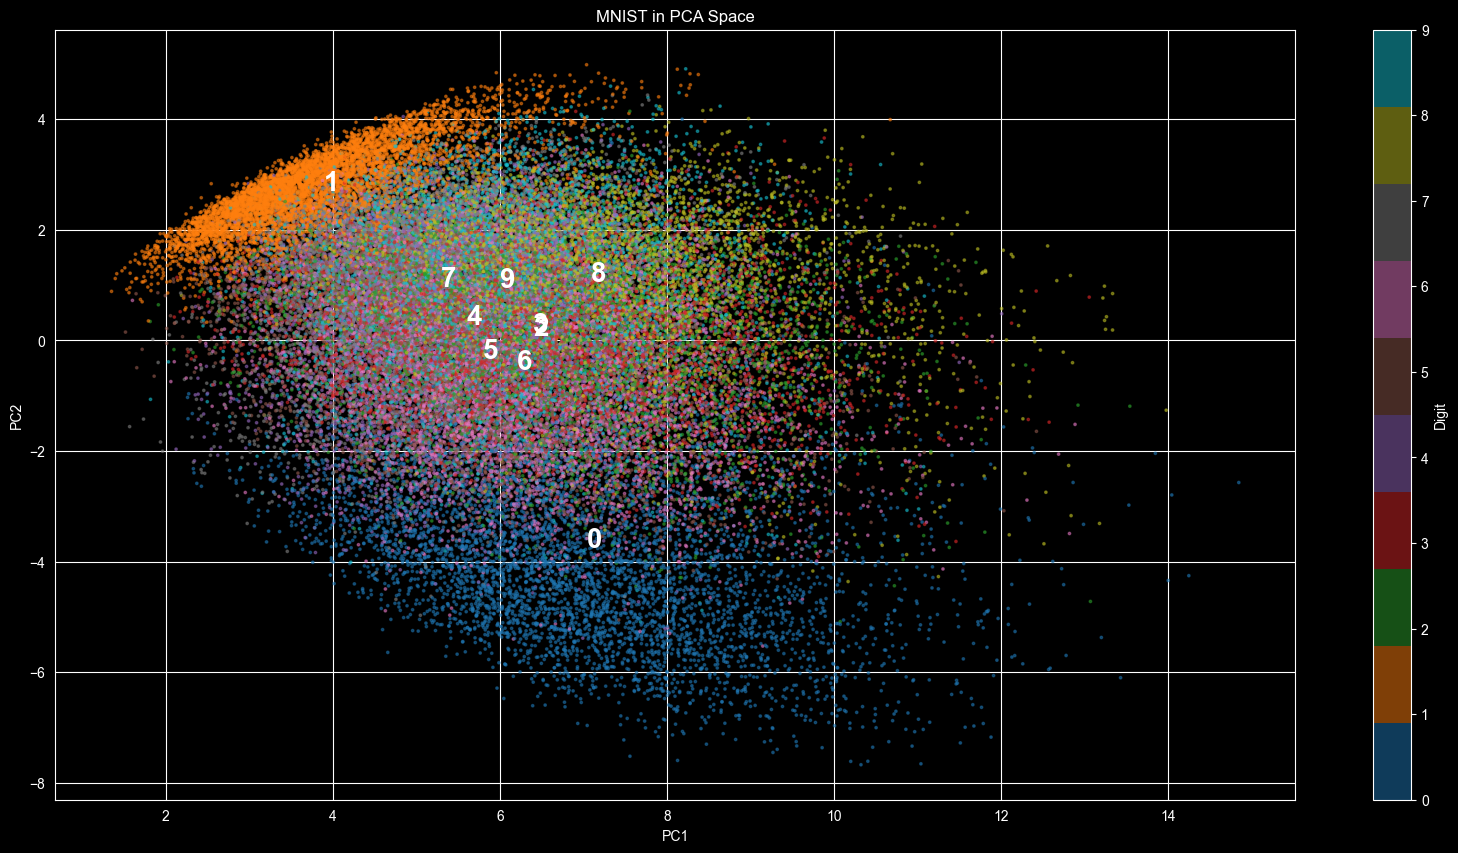

In [247]:
plt.figure(figsize=(20, 10))
plt.scatter(
    X_train_svd[:, 0],
    X_train_svd[:, 1],
    cmap="tab10",
    s=3,
    c=y_train,
    alpha=0.5,
)

for digit in range(10):
    x = X_train_svd[y_train == digit, 0].mean()
    y = X_train_svd[y_train == digit, 1].mean()

    plt.text(
        x, y,
        str(digit),
        fontsize=20,
        fontweight="bold"
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("MNIST in PCA Space")
plt.colorbar(label="Digit")

plt.show()


In [249]:
## Kernel PCA

In [248]:
kpca = KernelPCA(
    n_components=2,
    kernel="rbf",
    gamma=0.01
)

In [ ]:
X_train_kpca = kpca.fit_transform(X_train)
X_test_kpca = kpca.transform(X_test)

print(X_train_kpca.shape)
print(X_test_kpca.shape)

In [ ]:
plt.figure(figsize=(20, 10))

plt.scatter(
    X_train_kpca[:, 0],
    X_train_kpca[:, 1],
    c=y_train,
    cmap="tab10",
    s=3,
    alpha=0.5
)

for digit in range(10):
    x = X_train_kpca[y_train == digit, 0].mean()
    y = X_train_kpca[y_train == digit, 1].mean()

    plt.text(
        x, y,
        str(digit),
        fontsize=20,
        fontweight="bold"
    )

plt.xlabel("KPC1")
plt.ylabel("KPC2")
plt.title("MNIST with Kernel PCA")
plt.colorbar(label="Digit")
plt.show()

In [8]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np

X_5k = X_train.iloc[:5000]
y_5k = y_train.iloc[:5000]

In [9]:
tsne = TSNE(
    n_components=2,
    random_state=42
)

In [10]:
Z_tsne = tsne.fit_transform(X_5k)

print(Z_tsne.shape)

(5000, 2)


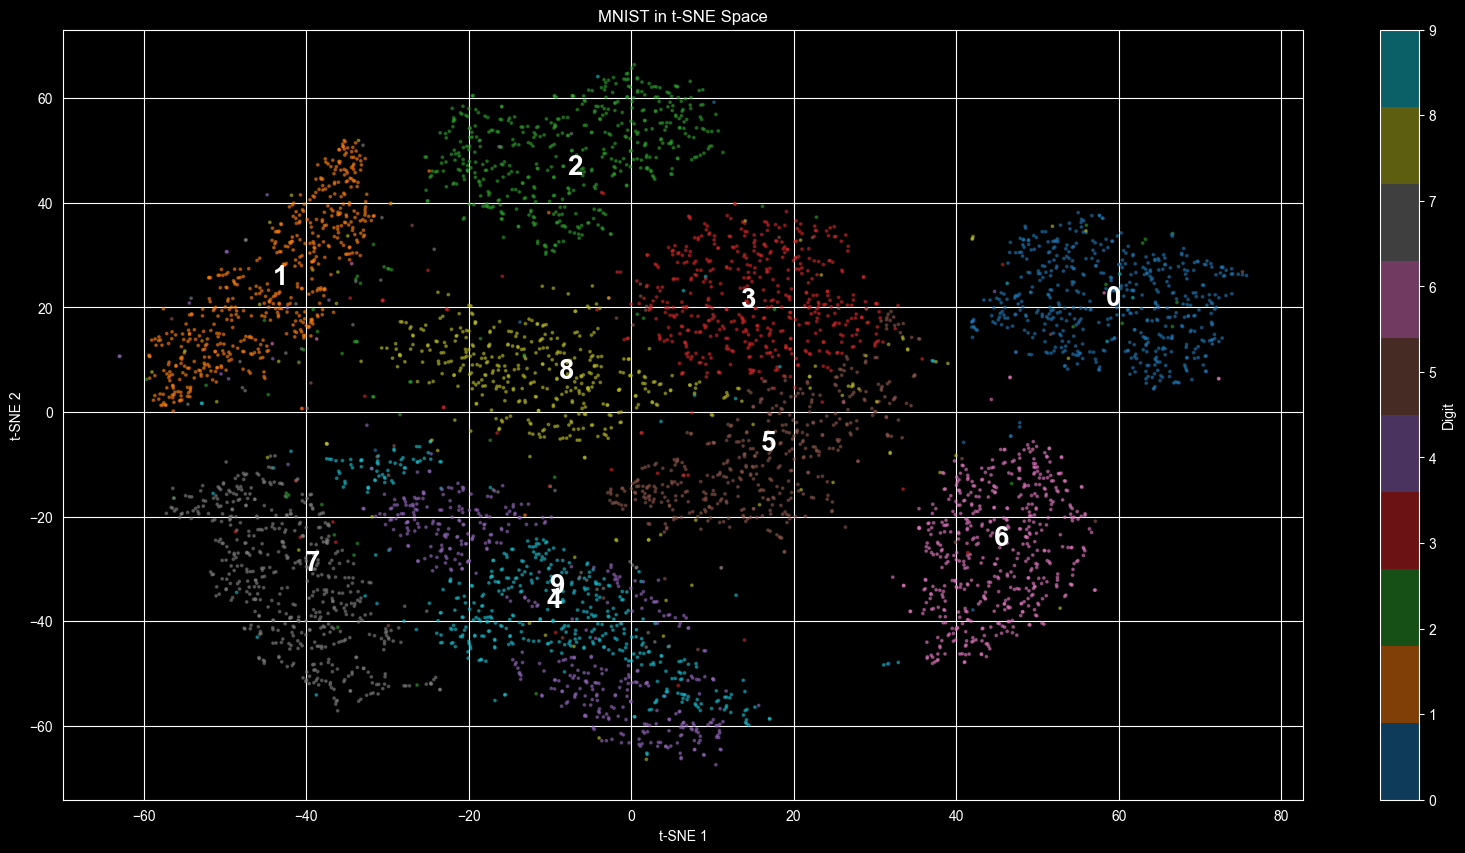

In [12]:
plt.figure(figsize=(20, 10))

plt.scatter(
    Z_tsne[:, 0],
    Z_tsne[:, 1],
    c=y_5k,
    cmap="tab10",
    s=3,
    alpha=0.5
)

for digit in range(10):
    x = Z_tsne[y_5k == digit, 0].mean()
    y = Z_tsne[y_5k == digit, 1].mean()

    plt.text(
        x, y,
        str(digit),
        fontsize=20,
        fontweight="bold"
    )

plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.title("MNIST in t-SNE Space")
plt.colorbar(label="Digit")

plt.show()